## Imports

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

# Detect environment and set data directory
if Path("/kaggle/input").exists():
    # Kaggle environment
    DATA_DIR = Path("/kaggle/input/competitions/playground-series-s6e9")
else:
    # Local environment
    PROJECT_ROOT = Path.cwd().parent
    DATA_DIR = PROJECT_ROOT / "data" / "raw"


print(f"Data directory: {DATA_DIR}")

Data directory: c:\Users\Darío\Desktop\KAGGLE\Predicting_Electric_Vehicle_Purchases\data\raw


## Data loading

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train shape: (668665, 15)
Test shape: (286571, 14)
Sample submission shape: (286571, 2)


## EDA 

In [3]:
print(train.shape)
train.head()

(668665, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [5]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,668665.0,NaN,NaN,NaN,334332.0,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,NaN,NaN,NaN,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,NaN,NaN,NaN,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,NaN,NaN,NaN,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,NaN,NaN,NaN,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,NaN,NaN,NaN,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,NaN,NaN,NaN,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,NaN,NaN,NaN,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Gender,668665,3,Male,367954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Type,668665,3,Urban,289305,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print(test.shape)
test.head()

(286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [7]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  str    
 9   City_Type                    286571 non-null  str    
 10  Current_Car_Type             286571 non-null  str    
 11  Home_Charging_Possible       286571 non-null  str    
 12  Subsidy_Available            286571 non-null  str    
 13  Range_Anxi

In [8]:
test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,286571.0,NaN,NaN,NaN,811950.0,82726.066333,668665.0,740307.5,811950.0,883592.5,955235.0
Age,286571.0,NaN,NaN,NaN,47.070824,12.86485,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,286571.0,NaN,NaN,NaN,84799.508432,28626.851098,30000.0,67380.0,84926.0,102751.0,186936.0
Daily_Commute_km,286571.0,NaN,NaN,NaN,32.159305,18.724436,5.0,17.2,33.6,47.3,103.9
Number_of_Cars_Owned,286571.0,NaN,NaN,NaN,1.716095,0.731088,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,286571.0,NaN,NaN,NaN,4.950693,3.928626,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,286571.0,NaN,NaN,NaN,7.155626,5.18688,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,286571.0,NaN,NaN,NaN,2.934554,1.427541,1.0,2.0,3.0,4.0,5.0
Gender,286571,3,Male,157647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Type,286571,3,Urban,123602,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As expected for a synthetic dataset, no missing values are present in either the training or test sets

In [9]:
train_stats = train.describe().T
test_stats = test.describe().T

comparison = pd.DataFrame({
    "train_mean": train_stats["mean"],
    "test_mean": test_stats["mean"],
    "mean_diff": test_stats["mean"] - train_stats["mean"],
    "train_std": train_stats["std"],
    "test_std": test_stats["std"],
    "std_diff": test_stats["std"] - train_stats["std"],
})

comparison

,train_mean,test_mean,mean_diff,train_std,test_std,std_diff
id,334332.000000,811950.000000,477618.000000,193027.103211,82726.066333,-110301.036878
Age,47.039171,47.070824,0.031653,12.875448,12.864850,-0.010598
Annual_Income_USD,84769.266989,84799.508432,30.241444,28648.029042,28626.851098,-21.177945
Daily_Commute_km,32.158298,32.159305,0.001008,18.730474,18.724436,-0.006038
Number_of_Cars_Owned,1.712626,1.716095,0.003469,0.729275,0.731088,0.001813
Charging_Stations_Near_Home,4.960408,4.950693,-0.009715,3.926843,3.928626,0.001783
Charging_Stations_Near_Work,7.176314,7.155626,-0.020688,5.186627,5.186880,0.000254
Environmental_Concern_Level,2.935477,2.934554,-0.000924,1.429119,1.427541,-0.001577


The numerical features show very similar descriptive statistics between the training and test sets, suggesting no major distribution shift.

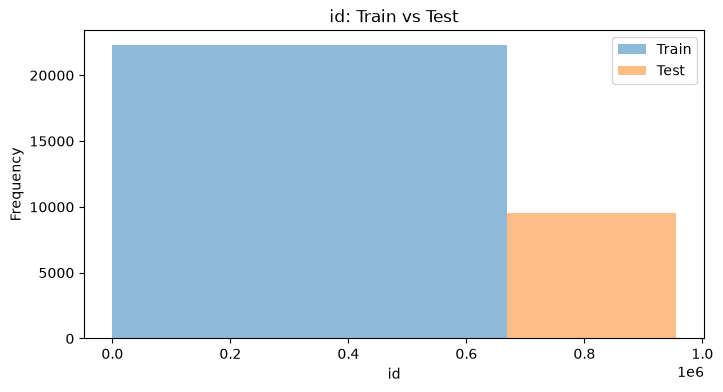

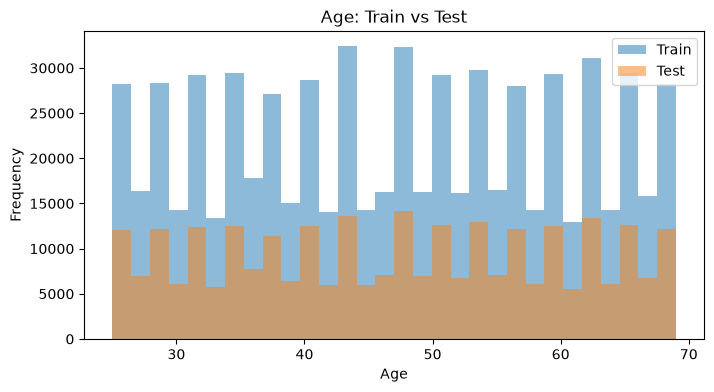

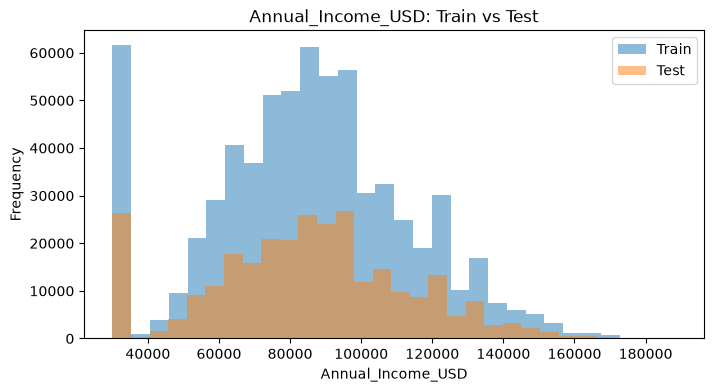

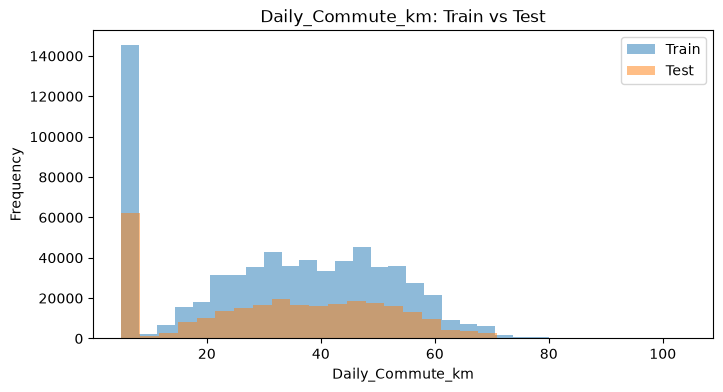

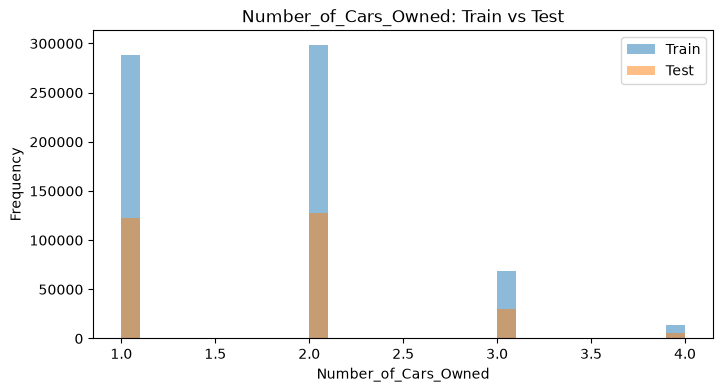

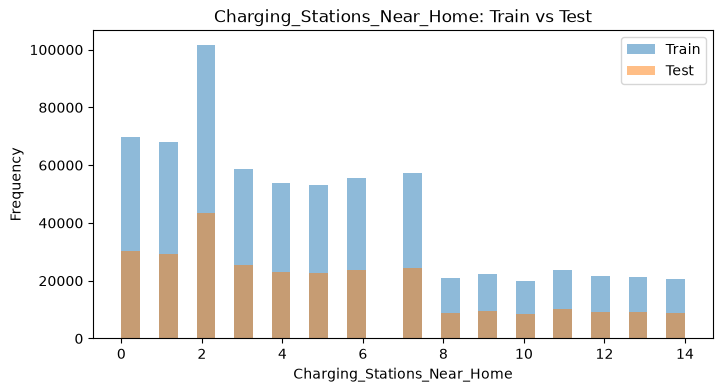

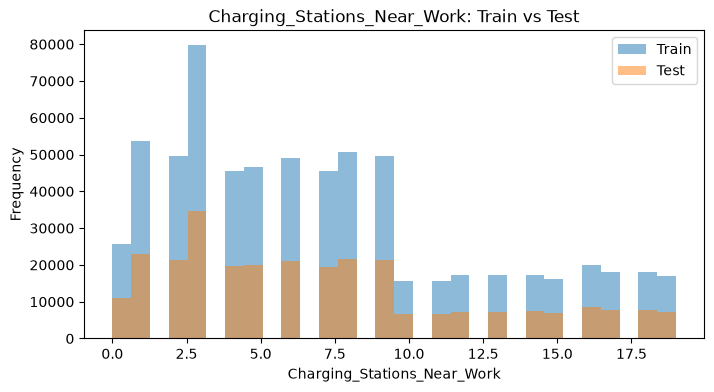

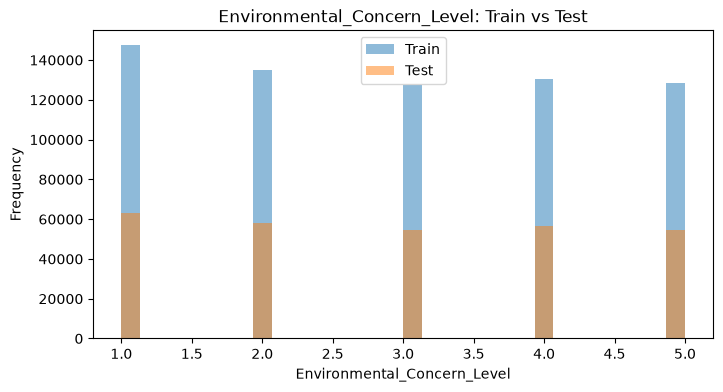

In [10]:
numeric_cols = train.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    
    plt.hist(train[col], bins=30, alpha=0.5, label="Train")
    plt.hist(test[col], bins=30, alpha=0.5, label="Test")
    
    plt.title(f"{col}: Train vs Test")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [11]:
target = "Will_Buy_EV"

categorical_cols = train.select_dtypes(
    include=["object", "category", "bool"]
).columns.drop(target, errors="ignore")

for col in categorical_cols:
    comparison = pd.concat(
        [
            train[col].value_counts(normalize=True).rename("train"),
            test[col].value_counts(normalize=True).rename("test")
        ],
        axis=1
    ).fillna(0)

    comparison["difference"] = comparison["test"] - comparison["train"]

    print(f"\n{'=' * 60}")
    print(col)
    display(comparison)


Gender


C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\4111763114.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(


,train,test,difference
Gender,,,
Male,0.550282,0.550115,-0.000167
Female,0.441816,0.442016,0.000200
Other,0.007902,0.007869,-0.000033



City_Type


,train,test,difference
City_Type,,,
Urban,0.432661,0.431314,-0.001347
Suburban,0.381921,0.382718,0.000798
Rural,0.185419,0.185968,0.000549


...

,train,test,difference
Home_Charging_Possible,,,
Yes,0.691941,0.692603,0.000662
No,0.308059,0.307397,-0.000662



Subsidy_Available


,train,test,difference
Subsidy_Available,,,
Yes,0.627981,0.629436,0.001455
No,0.372019,0.370564,-0.001455



Range_Anxiety_Level


,train,test,difference
Range_Anxiety_Level,,,
Low,0.903251,0.904652,0.001401
Medium,0.093468,0.091757,-0.001711
High,0.003281,0.003591,0.000310


No significant differences are observed between the training and test sets in terms of the distributions of their numerical and categorical features. Therefore, we will focus our analysis and subsequent preprocessing on the training set, assuming that the test set follows a similar distribution.

C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\4151621330.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(train[col].dropna(), vert=False)
C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\4151621330.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(train[col].dropna(), vert=False)
C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\4151621330.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(train[col].dropna(), vert=False)
C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\4151621330.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed 

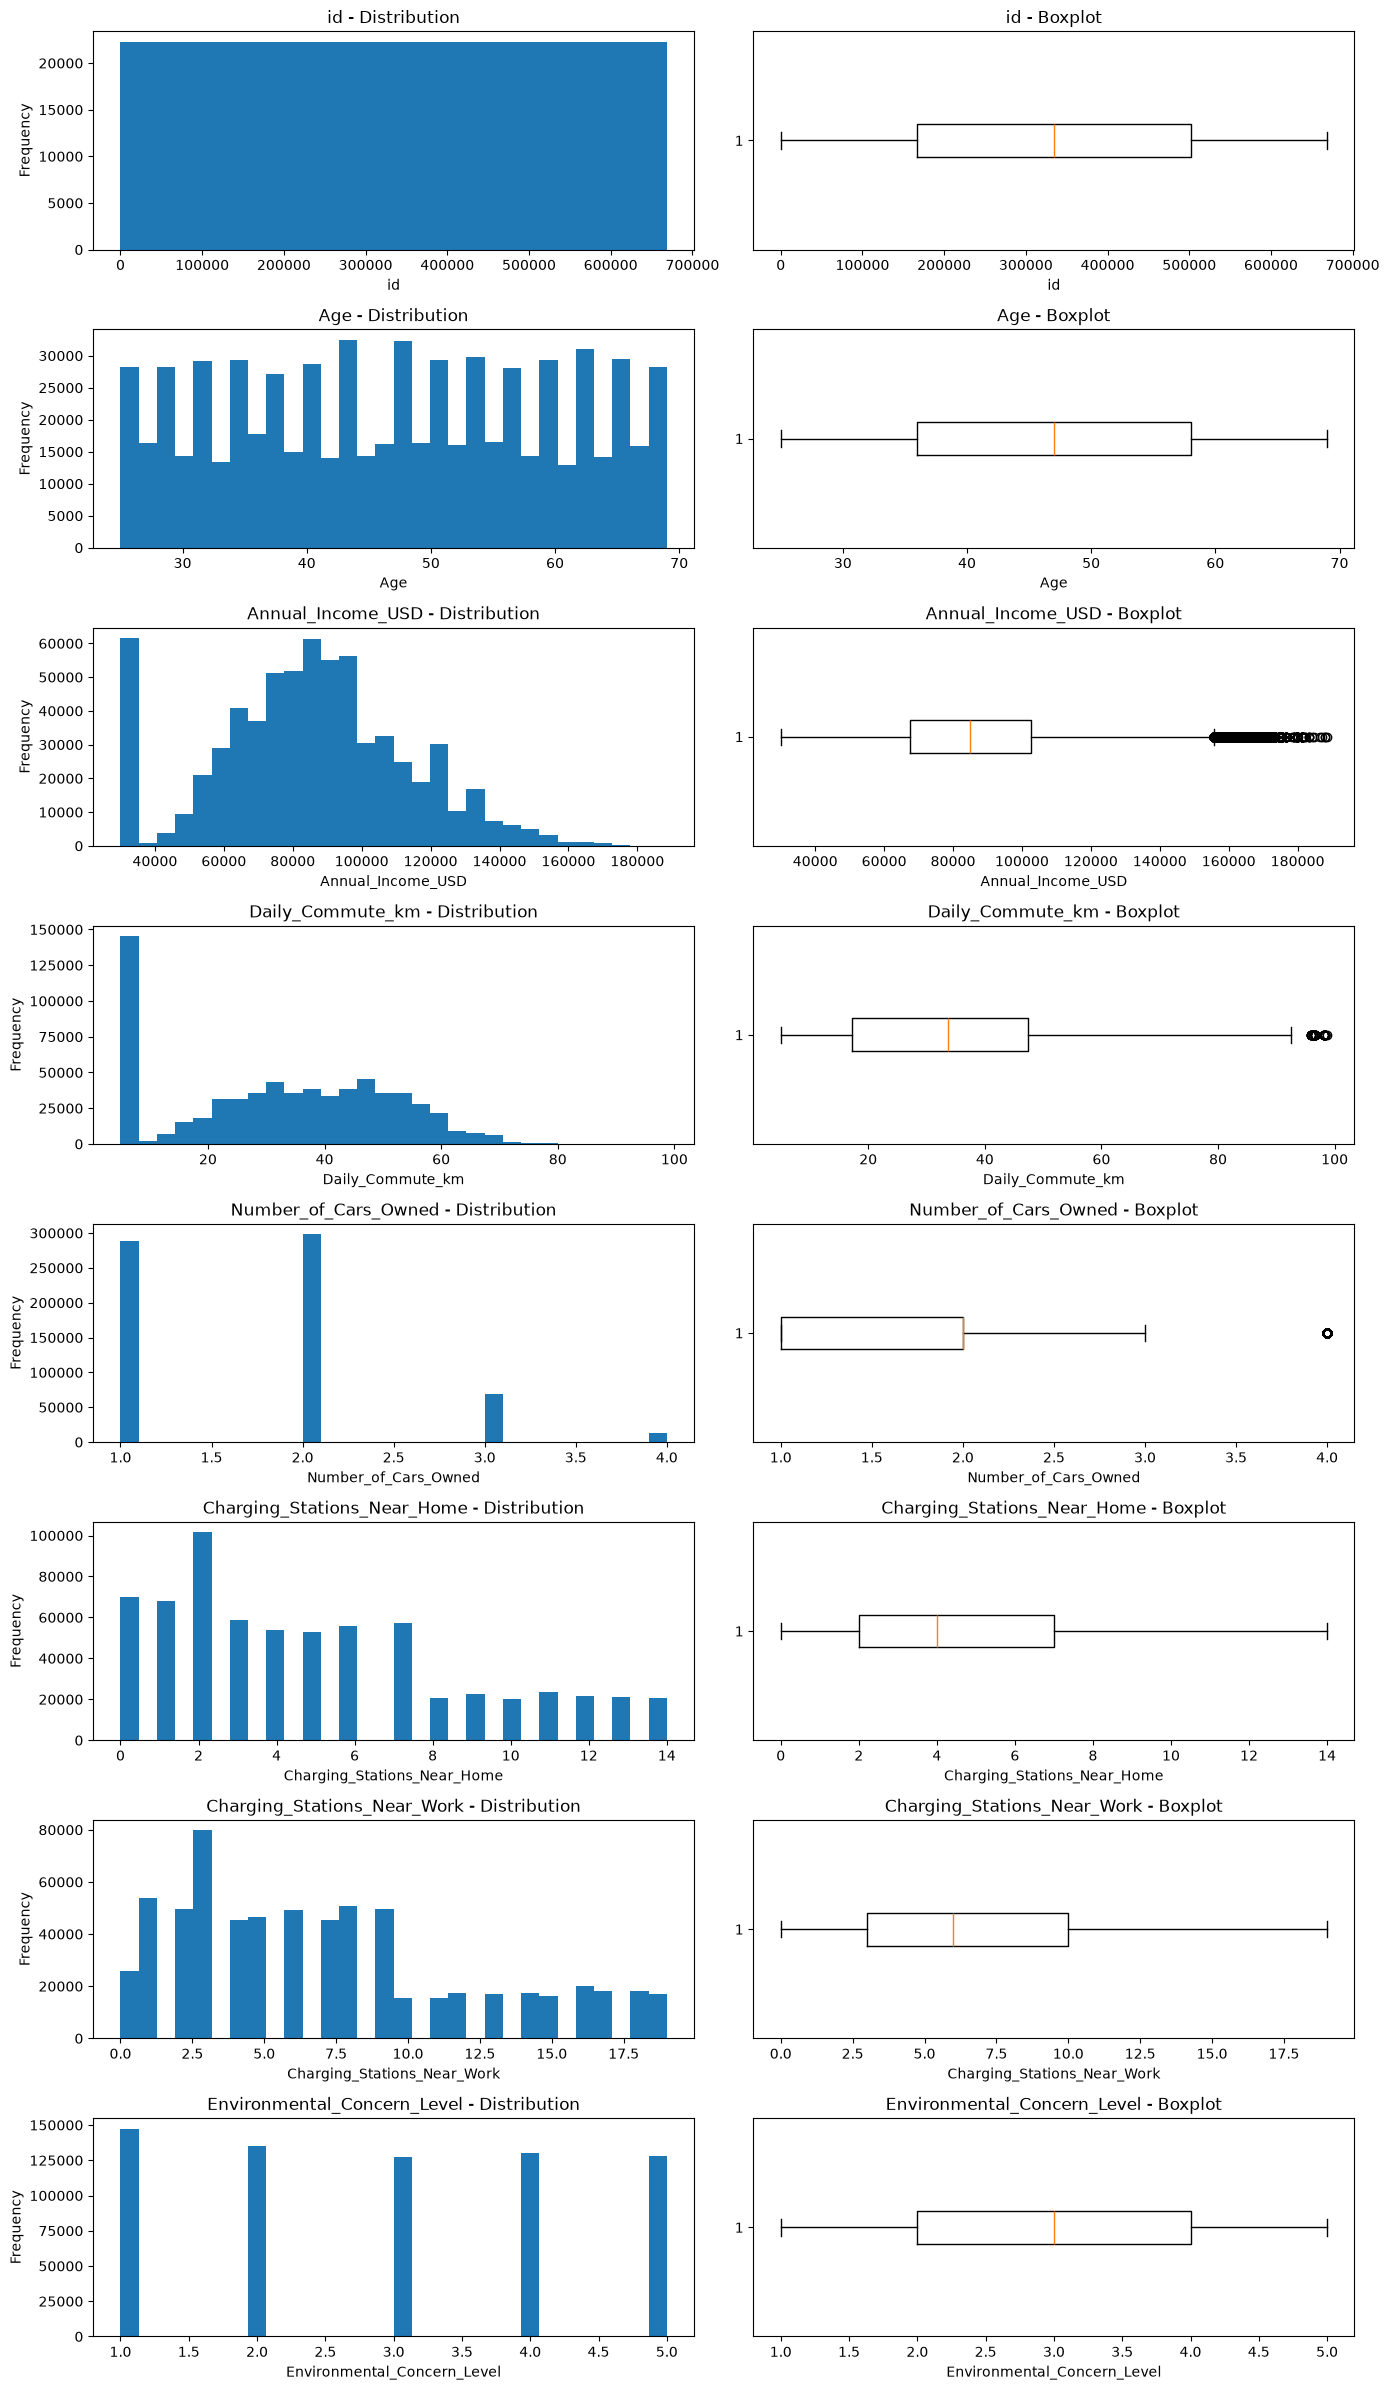

In [12]:
numeric_cols = train.select_dtypes(include="number").columns

n_cols = 2  # una variable por fila
n_rows = len(numeric_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i, 0].hist(train[col], bins=30)
    axes[i, 0].set_title(f"{col} - Distribution")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")

    # Boxplot
    axes[i, 1].boxplot(train[col].dropna(), vert=False)
    axes[i, 1].set_title(f"{col} - Boxplot")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

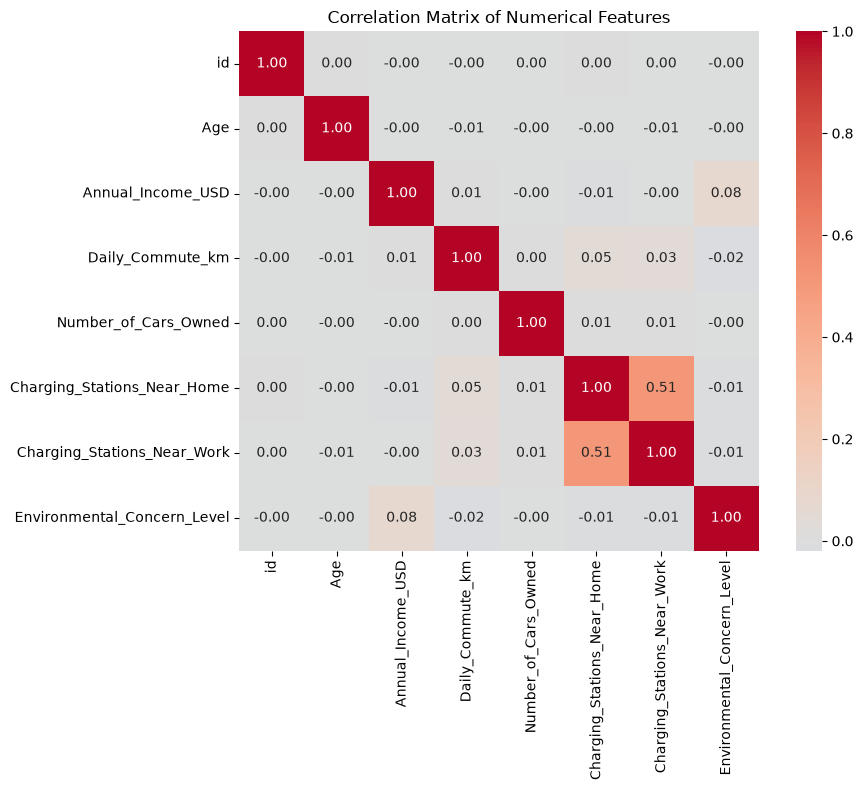

In [13]:
corr = train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

The strong correlation between the number of charging stations near home and near work may be explained by the fact that both variables are likely influenced by common factors, such as the availability of charging infrastructure in a given area or the user's location. Since the dataset is synthetic, this relationship may also reflect how the underlying data was generated.

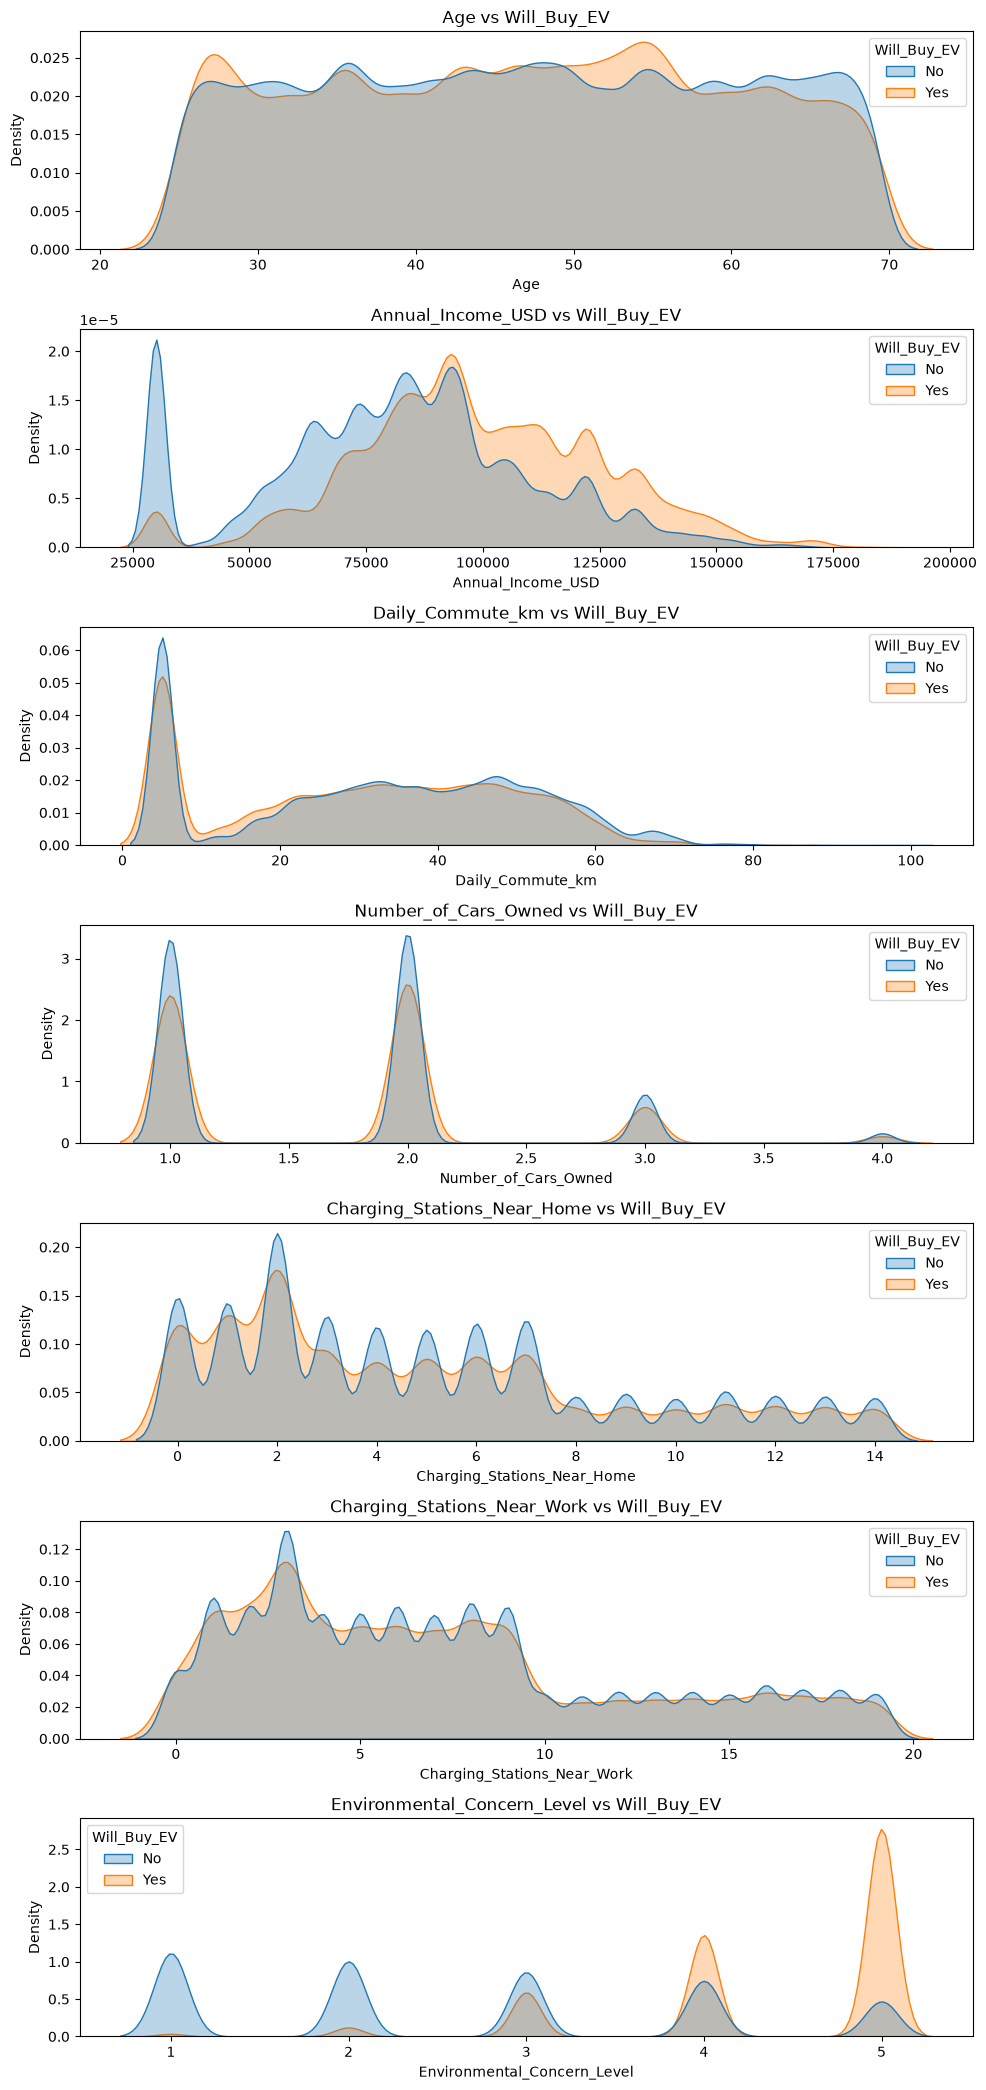

In [14]:
target = "Will_Buy_EV"

numeric_cols = train.select_dtypes(include="number").columns.drop(
    ["id", target], errors="ignore"
)

n_rows = len(numeric_cols)

fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(10, 3 * n_rows)
)

if n_rows == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(
        data=train,
        x=col,
        hue=target,
        fill=True,
        common_norm=False,
        alpha=0.3,
        ax=ax
    )

    ax.set_title(f"{col} vs {target}")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

The density plots reveal several interesting patterns regarding the relationship between the numerical features and the target variable. Age does not appear to differ substantially between people who purchase an electric vehicle and those who do not. In contrast, annual income seems to be an important factor, with higher-income individuals showing a greater tendency to purchase an electric vehicle.

Daily driving distance and the number of cars owned do not show noticeable differences between the two groups. Interestingly, the number of charging stations available near home or work also does not appear to be a major factor, as their distributions remain relatively similar regardless of the target class.

Finally, environmental concern stands out as one of the most relevant features. A clear difference can be observed between the two groups, with individuals with higher levels of environmental concern being considerably more likely to purchase an electric vehicle. This result is also consistent with the expected relationship between environmental awareness and EV adoption.

C:\Users\Darío\AppData\Local\Temp\ipykernel_37784\2068848530.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(


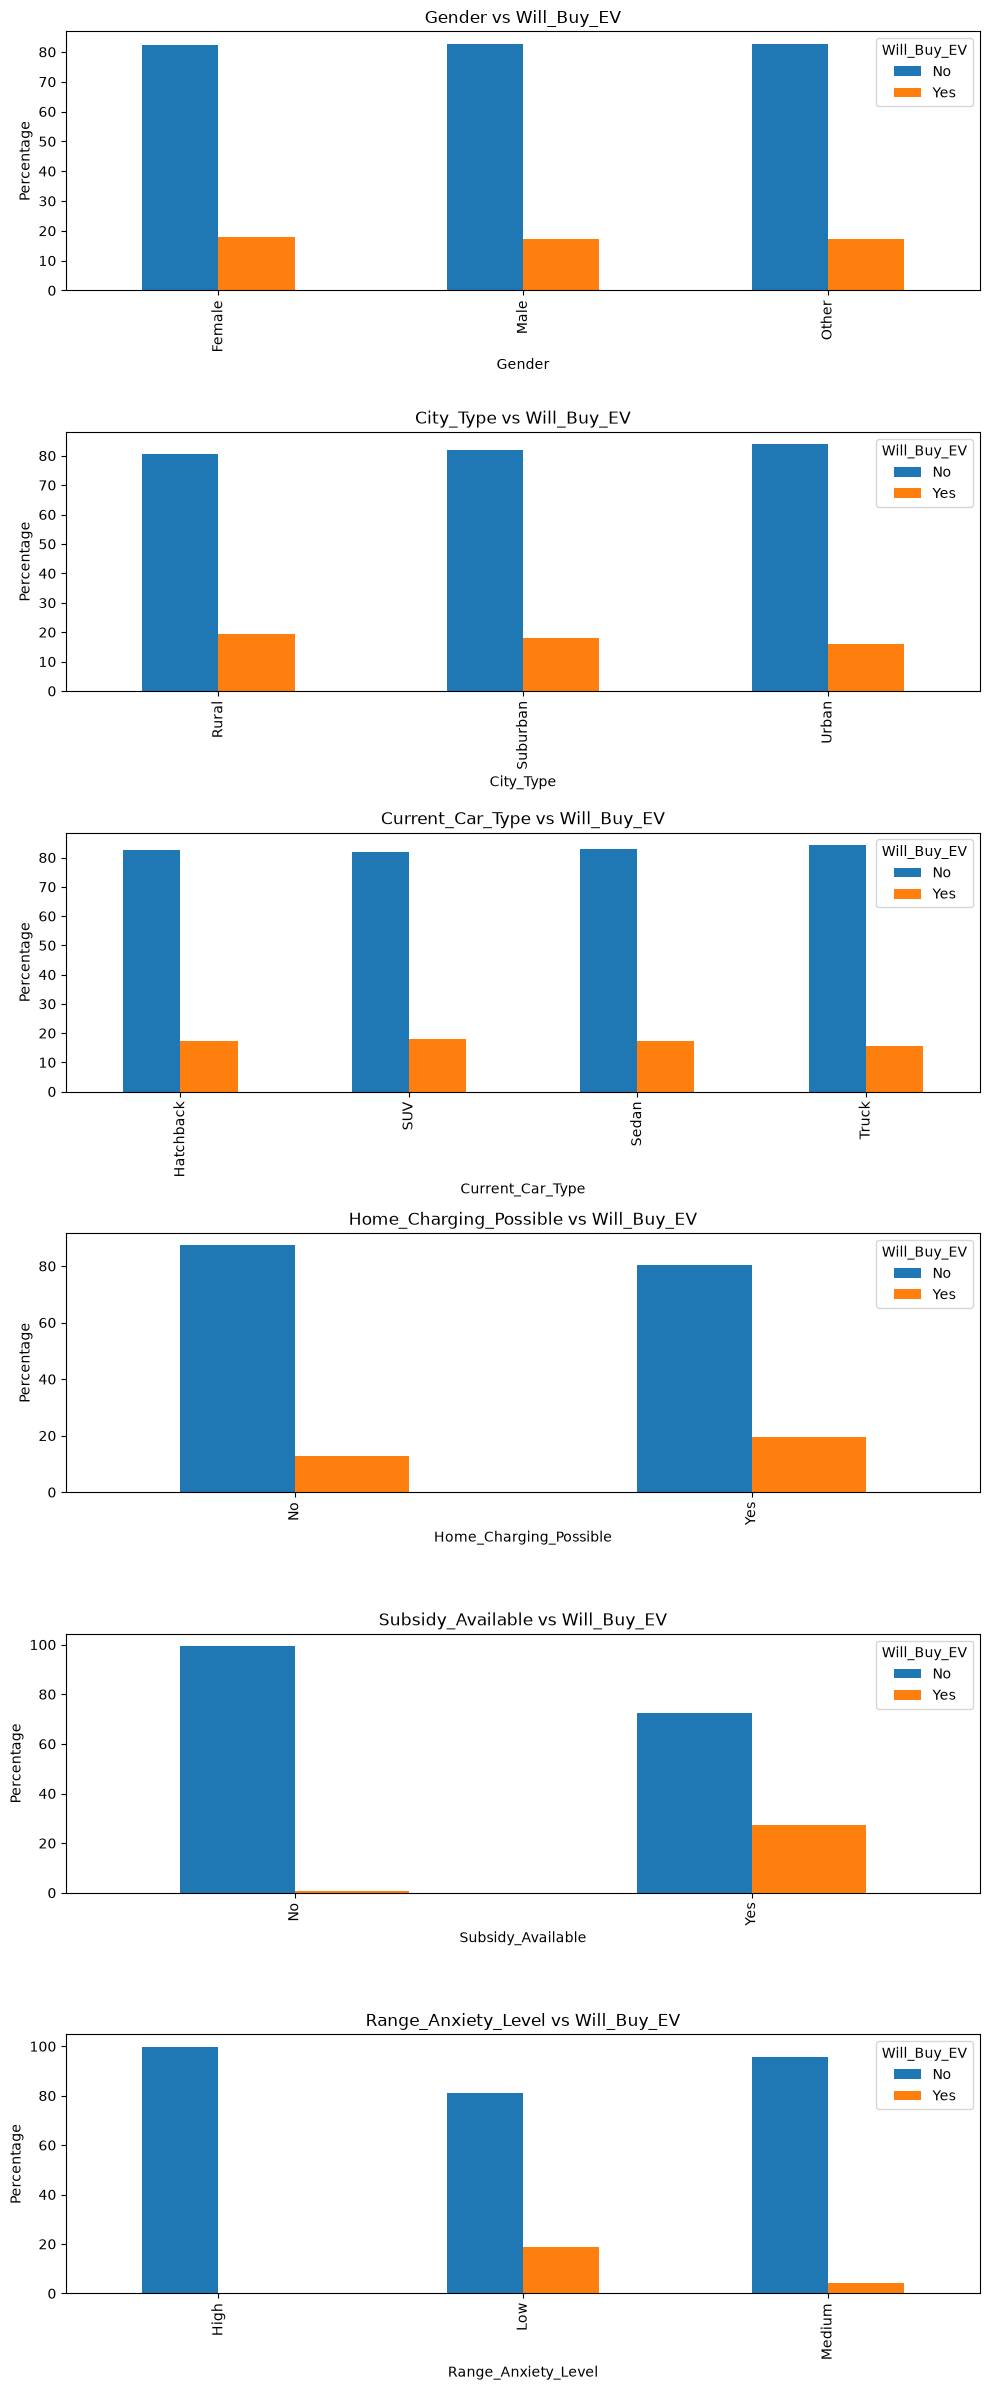

In [15]:
categorical_cols = train.select_dtypes(
    include=["object", "category", "bool"]
).columns.drop("Will_Buy_EV", errors="ignore")

n_rows = len(categorical_cols)

fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(10, 4 * n_rows)
)

if n_rows == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    proportions = pd.crosstab(
        train[col],
        train["Will_Buy_EV"],
        normalize="index"
    ) * 100

    proportions.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"{col} vs Will_Buy_EV")
    ax.set_ylabel("Percentage")
    ax.set_xlabel(col)
    ax.legend(title="Will_Buy_EV")

plt.tight_layout()
plt.show()

Among the categorical features, the most noticeable differences between the two target groups are observed for subsidy availability and range anxiety level. Individuals with access to a subsidy appear to be more likely to purchase an electric vehicle, which is consistent with the fact that financial incentives can reduce the effective cost of an EV. On the other hand, range anxiety also seems to play an important role, with individuals experiencing higher levels of concern about vehicle range being less likely to purchase an electric vehicle. This is also an intuitive relationship, as concerns about battery range and charging availability may act as a barrier to EV adoption.

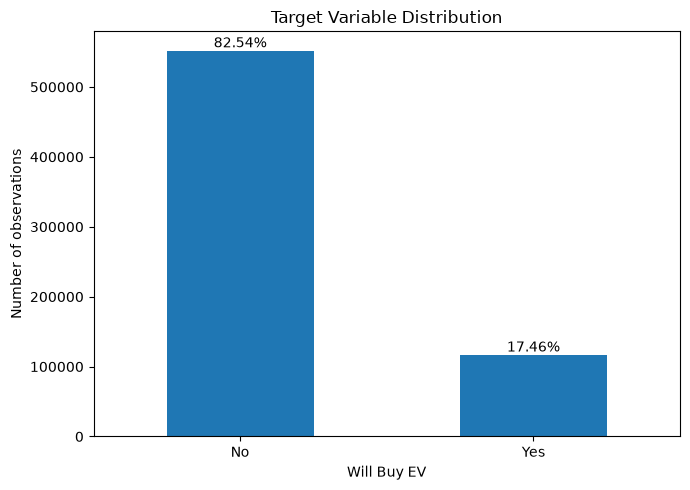

In [16]:
target_counts = train["Will_Buy_EV"].value_counts()

ax = target_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Target Variable Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)

total = len(train)

for i, value in enumerate(target_counts):
    percentage = value / total * 100
    ax.text(
        i,
        value,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The target variable is noticeably imbalanced. Approximately 82.5% of the observations correspond to individuals who do not purchase an electric vehicle, while only 17.5% correspond to individuals who do. This class imbalance should be taken into account when evaluating the models, as accuracy alone may provide a misleading picture of model performance. Therefore, ROC-AUC will be used as the primary evaluation metric, in accordance with the competition's evaluation criterion.